In [18]:
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import os
import pandas as pd


In [19]:
# Get all surface files, all saved in same directory
surf_dir = 'raw_data/FreeSurfer_Surfaces/40_depths'
surf_files = sorted([f for f in os.listdir(surf_dir) if f.startswith('rh.equi')])

print(f"{len(surf_files)} surface files")
depths = len(surf_files)

# array to store every vertex coordinate
all_vertex_coords = []
# array of tuples to store each vertex unique identifier (vertex_id, depth)
all_vertex_labels = []

for depth_idx, surf_filename in enumerate(surf_files):
    surf_file = os.path.join(surf_dir, surf_filename)
    
    #print(f"Depth {depth_idx}: {surf_filename}")
    
    coords, faces, volume_info = nib.freesurfer.read_geometry(surf_file, read_metadata=True)
    cras = np.array(volume_info['cras'])
    scanner_ras = coords + cras
    
    all_vertex_coords.append(scanner_ras)
    
    labels = [(v_id, depth_idx) for v_id in range(len(coords))]
    all_vertex_labels.extend(labels)

all_vertex_coords = np.vstack(all_vertex_coords)

print(f"\nTotal vertices: {len(all_vertex_coords):,}")
print(f"Shape: {all_vertex_coords.shape}")
print(f"length of all_vertex_labels: {len(all_vertex_labels)}")

41 surface files

Total vertices: 10,222,489
Shape: (10222489, 3)
length of all_vertex_labels: 10222489


In [20]:
# Load volume
volume = nib.load('raw_data/RHoccip_SGcrop.nii.gz')
print(f"Volume shape: {volume.shape}")
print(f"Total voxels: {np.prod(volume.shape):,}")

# Create grid of voxel indices
i, j, k = np.meshgrid(
    np.arange(volume.shape[0]),
    np.arange(volume.shape[1]),
    np.arange(volume.shape[2]),
    indexing='ij'
)

voxel_indices = np.column_stack([i.reshape(-1), j.reshape(-1), k.reshape(-1)])
print(f"Voxel indices shape: {voxel_indices.shape}")

# Transform to Scanner RAS using volume's affine
voxel_ras = apply_affine(volume.affine, voxel_indices)
print(f"Voxel RAS coordinates shape: {voxel_ras.shape}")

# Get intensities
intensities = volume.get_fdata().reshape(-1)
print(f"Intensities shape: {intensities.shape}")

Volume shape: (182, 274, 305)
Total voxels: 15,209,740
Voxel indices shape: (15209740, 3)
Voxel RAS coordinates shape: (15209740, 3)
Intensities shape: (15209740,)


In [21]:
SGmask = nib.load('raw_data/SG_mask_100um_extra_labels.nii.gz')
print(f"Volume Shape: {SGmask.shape}")
SGlabels = SGmask.get_fdata().reshape(-1)
print(f"labels shape: {SGlabels.shape}")



Volume Shape: (182, 274, 305)
labels shape: (15209740,)


In [22]:
from scipy.spatial import cKDTree

# Build KD tree from vertex coordinates in mm scanner ras
vertex_tree = cKDTree(all_vertex_coords)

print(f"Tree points: {vertex_tree.n}")

print(f"Voxels to query: {len(voxel_ras)}")

# Find nearest vertex for each voxel
distances, nearest_vertex_global_idx = vertex_tree.query(voxel_ras, k=1)

print(f"nearest_vertex_global_idx shape: {nearest_vertex_global_idx.shape}")

Tree points: 10222489
Voxels to query: 15209740
nearest_vertex_global_idx shape: (15209740,)


In [23]:
# Extract vertex_id and depth from global indices
all_vertex_labels_array = np.array(all_vertex_labels)
voxel_vertex_ids = all_vertex_labels_array[nearest_vertex_global_idx, 0]
voxel_depths = all_vertex_labels_array[nearest_vertex_global_idx, 1]

# create table
df = pd.DataFrame({
    'vertex_id': voxel_vertex_ids,
    'depth': voxel_depths,
    'intensity': intensities,
    'label': SGlabels
})

# Resolve SGlabels per vertex
def resolve_label(SGlabels):
    nonzero = SGlabels[SGlabels != 0]
    if len(nonzero) == 0:
        return 0
    if set(nonzero) == {1, 2}:  # Conflict
        return 1 if (nonzero == 1).sum() > (nonzero == 2).sum() else 2
    return int(nonzero.iloc[0])

vertex_labels_series = df.groupby('vertex_id')['label'].agg(resolve_label)

# Build profiles
profiles = df.groupby(['vertex_id', 'depth'])['intensity'].median().unstack()

# Combine
profiles['label'] = profiles.index.map(vertex_labels_series).fillna(0).astype(int)

print(profiles.head())

depth           0   1   2   3   4   5   6   7   8   9  ...  32  33  34  35  \
vertex_id                                              ...                   
525        3411.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
540        4267.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
584         552.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
585         565.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   
598        1125.5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN NaN NaN NaN   

depth      36  37  38  39  40  label  
vertex_id                             
525       NaN NaN NaN NaN NaN      0  
540       NaN NaN NaN NaN NaN      0  
584       NaN NaN NaN NaN NaN      0  
585       NaN NaN NaN NaN NaN      0  
598       NaN NaN NaN NaN NaN      0  

[5 rows x 42 columns]


In [24]:
print(len(df))

15209740


Total labeled profiles: 5478
  SG (label=1): 2966
  Non-SG (label=2): 2512


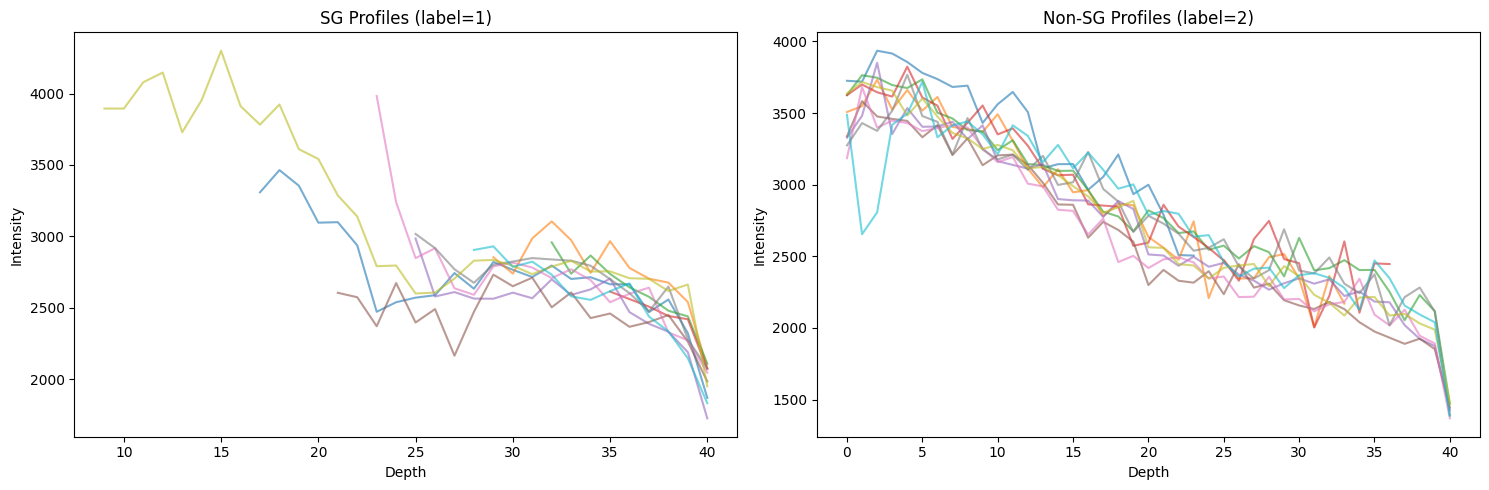

In [25]:
import matplotlib.pyplot as plt

# Get labeled profiles
labeled_profiles = profiles[profiles['label'] != 0].copy()

print(f"Total labeled profiles: {len(labeled_profiles)}")
print(f"  SG (label=1): {(labeled_profiles['label'] == 1).sum()}")
print(f"  Non-SG (label=2): {(labeled_profiles['label'] == 2).sum()}")

# Plot first 20 SG profiles
sg_profiles = labeled_profiles[labeled_profiles['label'] == 1]
depth_cols = list(range(41))  # Depths 0-40

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# SG profiles
for i, (vertex_id, row) in enumerate(sg_profiles.head(10).iterrows()):
    intensities = row[depth_cols].values
    ax1.plot(intensities, alpha=0.6, label=f'v{vertex_id}')
ax1.set_title('SG Profiles (label=1)')
ax1.set_xlabel('Depth')
ax1.set_ylabel('Intensity')

# Non-SG profiles
non_sg_profiles = labeled_profiles[labeled_profiles['label'] == 2]
for i, (vertex_id, row) in enumerate(non_sg_profiles.head(10).iterrows()):
    intensities = row[depth_cols].values
    ax2.plot(intensities, alpha=0.6, label=f'v{vertex_id}')
ax2.set_title('Non-SG Profiles (label=2)')
ax2.set_xlabel('Depth')
ax2.set_ylabel('Intensity')

plt.tight_layout()
plt.show()

In [ ]:

# Extract middle depths (6-34) - artefacts at boundaries and not required for SG
middle_depths = list(range(6, 35))

# Create feature_df
feature_df = profiles[middle_depths].copy()
feature_df.insert(0, 'col_id', profiles.index)  # Add vertex_id as col_id column

# Remove vertices with NaN in middle depths
n_before = len(feature_df)
feature_df = feature_df.dropna(subset=middle_depths)
n_after = len(feature_df)

print(f"before: {n_before} after: {n_after}")

# Create label dict
label_dict = profiles['label'].to_dict()

# add label column to features
feature_df['label'] = feature_df['col_id'].map(profiles['label']).fillna(0)

# Filter out label=0 (unlabelled in the mask)
feature_df_labeled = feature_df[feature_df['label'] != 0].copy()

print(f"\nLabeled vertices: {len(feature_df_labeled)}")
print(f"  SG: {(feature_df_labeled['label'] == 1).sum()}")
print(f"  Non-SG: {(feature_df_labeled['label'] == 2).sum()}")

# Create label_dict from labeled data only
label_dict_filtered = feature_df_labeled.set_index('col_id')['label'].to_dict()


before: 11640 after: 9456

Labeled vertices: 5148
  SG: 2861
  Non-SG: 2287


In [ ]:
# Train with raw intensities
from src.classifier_training import prepare_training_data, train_rf_model, evaluate_model

X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_training_data(
    feature_df_labeled.drop('label', axis=1), 
    label_dict_filtered, 
    features_to_use=middle_depths  # Use raw intensities as features
)

In [ ]:
from src.CNN_train import prepare_cnn_data, train_cnn_model, plot_training_history, evaluate_cnn_model, predict_cnn_probabilities

# Prepare data for CNN
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = prepare_cnn_data(
    X_train_scaled, X_test_scaled, y_train, y_test
)

In [ ]:
# Train CNN
cnn_model, history = train_cnn_model(
    X_train_cnn, y_train_cnn,
    X_test_cnn, y_test_cnn,
    epochs=100,
    batch_size=32,
    patience=15,
    verbose=1
)

In [ ]:
# Visualize training
plot_training_history(history)

# Evaluate
preds, probs = evaluate_cnn_model(cnn_model, X_test_cnn, y_test_cnn, model_name='cnn')

In [ ]:
# Predict on full dataset
feature_df_with_cnn_probs = predict_cnn_probabilities(
    feature_df,
    cnn_model,
    scaler,
    middle_depths,
    model_name='cnn'
)

In [27]:
# Train with raw intensities
from src.classifier_training import prepare_training_data, train_rf_model, evaluate_model

X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_training_data(
    feature_df_labeled.drop('label', axis=1), 
    label_dict_filtered, 
    features_to_use=middle_depths  # Use raw intensities as features
)

rf_model = train_rf_model(X_train_scaled, y_train)
preds, probs = evaluate_model(rf_model, X_test_scaled, y_test, model_name='rf')


Evaluation for rf
              precision    recall  f1-score   support

           1       0.88      0.77      0.82      1166
           2       0.74      0.86      0.80       894

    accuracy                           0.81      2060
   macro avg       0.81      0.82      0.81      2060
weighted avg       0.82      0.81      0.81      2060

rf ROC-AUC: 0.884


In [33]:
from src.classifier_training import predict_sg_probabilities
# Predict on full dataset
feature_df_with_probs = predict_sg_probabilities(
    feature_df,  # Full feature_df
    rf_model, 
    scaler, 
    model_name='rf'
)



In [34]:
# Create vertex_id to probability mapping
vertex_id_to_prob = feature_df_with_probs.set_index('col_id')['rf_sg_probability'].to_dict()

In [35]:
from collections import defaultdict

# Build mapping of vertex_id to voxel coordinates
vertex_to_voxel_coords = defaultdict(list)

for i in range(len(voxel_indices)):
    vertex_id = voxel_vertex_ids[i]
    depth = voxel_depths[i]
    distance = distances[i]
    voxel_coord = voxel_indices[i]  # [i, j, k] coordinates
    
    # Filter only middle depths
    if depth < 2 or depth >= 38:
        continue
    
    # Filter only voxels close to vertices
    if distance > 1: # 1mm 
        continue
    
    # Store voxel coordinate for this vertex
    vertex_to_voxel_coords[vertex_id].append(tuple(voxel_coord))

print(f"Mapped {len(vertex_to_voxel_coords)} unique vertices to voxels")

Mapped 10912 unique vertices to voxels


In [37]:
# Create empty 3D volume
prob_map = np.zeros(volume.shape)  # volume is your RHoccip_SGcrop.nii.gz

# Fill in probabilities
for vertex_id, voxel_coords in vertex_to_voxel_coords.items():
    # Get this vertex's probability (if it has one)
    if vertex_id not in vertex_id_to_prob:
        continue  # Skip vertices without predictions (e.g., had NaN in features)
    
    prob = vertex_id_to_prob[vertex_id]
    
    # Assign probability to all voxels for this vertex
    for (i, j, k) in voxel_coords:
        prob_map[i, j, k] = prob

print(f"Non-zero voxels in probability map: {np.count_nonzero(prob_map)}")

import nibabel as nib

# Save using same affine as your input volume
prob_nifti = nib.Nifti1Image(prob_map, volume.affine)
nib.save(prob_nifti, 'outputs/sg_probability_map_vertices_test1.nii.gz')
print("Saved probability map to outputs/")

Non-zero voxels in probability map: 6782369
Saved probability map to outputs/


In [38]:
print("Model classes:", rf_model.classes_)

Model classes: [1 2]


In [39]:
# Run this to check
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train: [1 2]
Unique labels in y_test: [1 2]


In [40]:
# Check what you have after prepare_training_data
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_scaled shape: (3088, 29)
X_test_scaled shape: (2060, 29)
y_train shape: (3088,)
y_test shape: (2060,)


In [41]:
# Check what's in your full dataset
print("feature_df columns:", feature_df.columns.tolist())
print("feature_df shape:", feature_df.shape)
print("middle_depths:", middle_depths)

feature_df columns: ['col_id', 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 'label']
feature_df shape: (9456, 31)
middle_depths: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]


In [42]:
# Check if your scaler is already fitted
print("Scaler mean:", scaler.mean_[:5] if hasattr(scaler, 'mean_') else "Not StandardScaler")
print("Scaler scale:", scaler.scale_[:5] if hasattr(scaler, 'scale_') else "Not StandardScaler")

Scaler mean: [2539.08452073 2529.83354922 2518.2263601  2501.37807642 2481.81881477]
Scaler scale: [250.70311388 243.11160451 242.30685766 236.89945743 235.27937442]


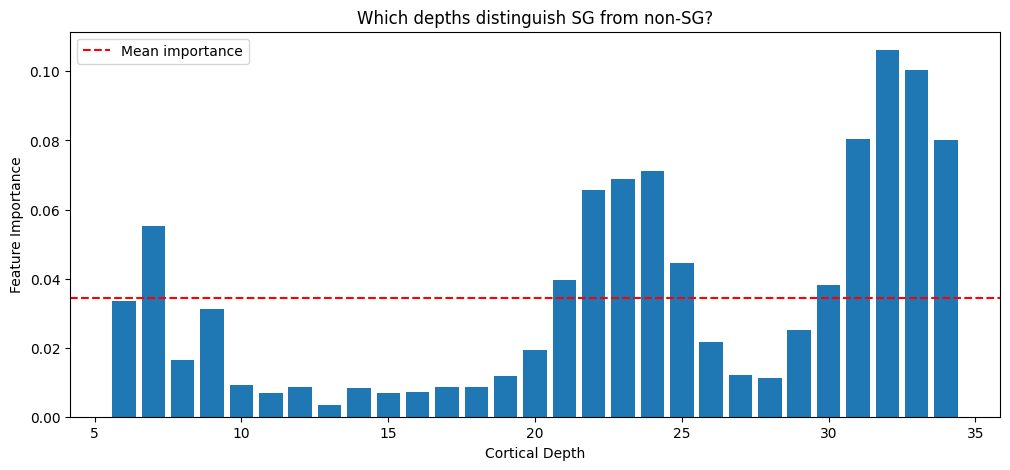

In [28]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_model.feature_importances_
depths = middle_depths

plt.figure(figsize=(12, 5))
plt.bar(depths, importances)
plt.xlabel('Cortical Depth')
plt.ylabel('Feature Importance')
plt.title('Which depths distinguish SG from non-SG?')
plt.axhline(y=np.mean(importances), color='r', linestyle='--', label='Mean importance')
plt.legend()
plt.show()

In [29]:
from src.extract_features import compute_features

# profiles df to dict for compute_features
def dataframe_to_profile_dict(df, depth_columns):
    profiles_dict = {}
    for idx, row in df.iterrows():
        vertex_id = row['col_id']
        depths = np.array(depth_columns)
        intensities = row[depth_columns].values
        profiles_dict[vertex_id] = (depths, intensities)
    return profiles_dict

# extract features
vertex_profiles = dataframe_to_profile_dict(feature_df_labeled, middle_depths)
feature_df_eng = compute_features(vertex_profiles, threshold_factor=0.03) 



In [30]:
# Add labels and filter
feature_df_eng['label'] = feature_df_eng['col_id'].map(label_dict_filtered)


print(f"Profiles with features: {len(feature_df_eng)}")


Profiles with features: 5148


In [31]:

# train with extracted features
feature_columns = ['dip_width', 'dip_depth_diff', 'post_dip_ratio', 'second_derivative_max']

X_train_eng, X_test_eng, y_train_eng, y_test_eng, scaler_eng = prepare_training_data(
    feature_df_eng.drop('label', axis=1),
    feature_df_eng.set_index('col_id')['label'].to_dict(),
    features_to_use=feature_columns
)

rf_model_eng = train_rf_model(X_train_eng, y_train_eng)
preds_eng, probs_eng = evaluate_model(rf_model_eng, X_test_eng, y_test_eng, model_name='rf_eng')


Evaluation for rf_eng
              precision    recall  f1-score   support

           1       0.91      0.67      0.77      1166
           2       0.68      0.91      0.78       894

    accuracy                           0.77      2060
   macro avg       0.79      0.79      0.77      2060
weighted avg       0.81      0.77      0.77      2060

rf_eng ROC-AUC: 0.846


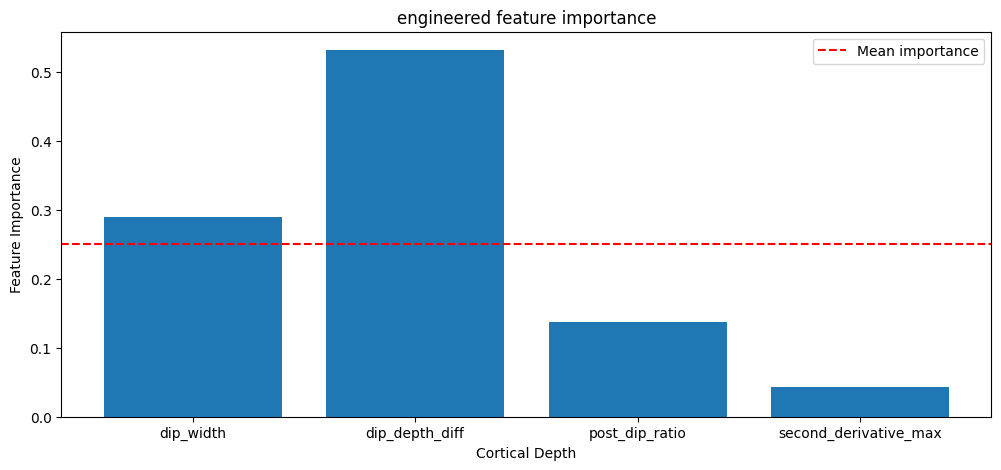

In [32]:
import matplotlib.pyplot as plt

# feature importances
importances = rf_model_eng.feature_importances_ 


plt.figure(figsize=(12, 5))
plt.bar(feature_columns, importances)
plt.xlabel('Cortical Depth')
plt.ylabel('Feature Importance')
plt.title('engineered feature importance')
plt.axhline(y=np.mean(importances), color='r', linestyle='--', label='Mean importance')
plt.legend()
plt.show()

In [ ]:
from src.outputs import save_column_map_to_nifti

save_column_map_to_nifti(
    feature_df=feature_df,
    column_data=column_data,
    value_col="rf_sg_probability_smoothed",
    affine=volume.affine,
    output_path="SG_RF_smoothed_probability_map_100.nii"
)